# Notebook 01 — Web Scraping Ulasan Aplikasi EWA

Fase CRISP-DM : Data Understanding
Input : Google Play Store (data publik)
Output : dataset_raw_ewa_acsc.csv, summary_app_info.csv, audit_scraping_log.txt, raw_<app>.csv
Tools : google-play-scraper, pandas

---
## STEP 0: Install Library & Import

Library google-play-scraper dipilih karena dirancang khusus untuk mengakses data publik Google Play Store, tidak memerlukan API key, dan mendukung pengambilan ulasan secara batch dengan paginasi otomatis. Data yang diambil adalah ulasan publik yang ditampilkan terbuka di halaman aplikasi.

In [ ]:
!pip install google-play-scraper -q

In [ ]:
import os
import time
import warnings
import pandas as pd
import numpy  as np
from datetime import datetime, timezone
from google_play_scraper import app as gps_app
from google_play_scraper import reviews_all
from google_play_scraper import Sort

warnings.filterwarnings('ignore')

SCRAPING_DATE = datetime.now().strftime('%Y-%m-%d')

print('Library siap.')
print(f'   Tanggal scraping : {SCRAPING_DATE}')
print(f'   pandas version   : {pd.__version__}')

Library siap.
   Tanggal scraping : 2026-05-16
   pandas version   : 2.2.2


---
## STEP 1: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## STEP 2: Konfigurasi Path

Rentang waktu scraping: Januari 2020 - Mei 2026.
Justifikasi: Mayoritas aplikasi EWA di Indonesia mulai aktif beroperasi pada 2020.  
Batas akhir Mei 2026 ditetapkan sebagai cutoff tetap untuk memastikan konsistensi snapshot data.

### Struktur Folder Google Drive:
```
TA_ACSC_EWA/
└── 01_scraping/
    └── data/
        ├── dataset_raw_ewa_acsc.csv
        ├── summary_app_info.csv
        └── audit_scraping_log.txt
```

In [ ]:
BASE_PATH    = '/content/drive/MyDrive/TA_ACSC_EWA'
SCRAPING_DIR = os.path.join(BASE_PATH, '01_scraping', 'data')
os.makedirs(SCRAPING_DIR, exist_ok=True)

RAW_FILE     = os.path.join(SCRAPING_DIR, 'dataset_raw_ewa_acsc.csv')
SUMMARY_FILE = os.path.join(SCRAPING_DIR, 'summary_app_info.csv')
AUDIT_FILE   = os.path.join(SCRAPING_DIR, 'audit_scraping_log.txt')

APPS = [
    {'app_name': 'VENTENY',    'package_name': 'app.fortuna.venteny',         'note': 'Platform EWA terintegrasi dengan ekosistem employee welfare'},
    {'app_name': 'Mekari Flex','package_name': 'com.mekari.flex',             'note': 'Platform EWA dari Mekari Group, terintegrasi dengan sistem payroll'},
    {'app_name': 'Paywatch',   'package_name': 'my.paywatchglobal.paywatch',  'note': 'Platform EWA internasional beroperasi di Asia Tenggara termasuk Indonesia'},
    {'app_name': 'Wagely',     'package_name': 'com.wagely.android',          'note': 'Platform EWA berbasis Indonesia, fokus segmen karyawan menengah ke bawah'},
    {'app_name': 'GajiGesa',   'package_name': 'com.gajigesanative',          'note': 'Platform EWA lokal Indonesia dengan basis pengguna terbesar'},
    {'app_name': 'AyoKasbon',  'package_name': 'com.kasbon.id',               'note': 'Platform EWA lokal Indonesia — ditambahkan pada revisi penelitian'},
]

# Konfigurasi scraping
LANG       = 'id'
COUNTRY    = 'id'
SORT_ORDER = Sort.NEWEST

DATE_START = datetime(2020, 1,  1,  tzinfo=timezone.utc)   # 1 Januari 2020
DATE_END   = datetime(2026, 5,  31, tzinfo=timezone.utc)   # 31 Mei 2026

# Delay antar request untuk menghindari rate limit
DELAY_BETWEEN_APPS = 5

# Kolom yang diambil dari API
COLS_KEEP = ['reviewId', 'userName', 'content', 'score', 'at']

# Verifikasi konfigurasi
print('Konfigurasi dimuat.')
print(f'   Base path      : {BASE_PATH}')
print(f'   Jumlah aplikasi: {len(APPS)} aplikasi EWA')
print(f'   Rentang waktu  : {DATE_START.strftime("%d %B %Y")} s.d. {DATE_END.strftime("%d %B %Y")}')
print(f'   Bahasa/Negara  : {LANG}/{COUNTRY}')
print()
print('Daftar aplikasi yang akan di-scraping:')
for i, a in enumerate(APPS, 1):
    print(f'  [{i}] {a["app_name"]:<15} | {a["package_name"]}')

Konfigurasi dimuat.
   Base path      : /content/drive/MyDrive/TA_ACSC_EWA
   Jumlah aplikasi: 6 aplikasi EWA
   Rentang waktu  : 01 January 2020 s.d. 31 May 2026
   Bahasa/Negara  : id/id

Daftar aplikasi yang akan di-scraping:
  [1] VENTENY         | app.fortuna.venteny
  [2] Mekari Flex     | com.mekari.flex
  [3] Paywatch        | my.paywatchglobal.paywatch
  [4] Wagely          | com.wagely.android
  [5] GajiGesa        | com.gajigesanative
  [6] AyoKasbon       | com.kasbon.id


---
## STEP 3: Ambil Metadata Aplikasi

In [ ]:
print('Mengambil metadata aplikasi dari Google Play Store...')
print('=' * 70)

metadata_list = []

for app_info in APPS:
    pkg  = app_info['package_name']
    name = app_info['app_name']
    try:
        meta = gps_app(pkg, lang=LANG, country=COUNTRY)
        metadata_list.append({
            'app_name'    : name,
            'package_name': pkg,
            'rating'      : round(meta.get('score', 0), 2),
            'total_rating': meta.get('ratings', 0),
            'total_review': meta.get('reviews', 0),
            'installs'    : meta.get('realInstalls', 0),
            'developer'   : meta.get('developer', 'N/A'),
            'status'      : 'Aktif '
        })
        print(f'  {name:<15} | Rating: {meta.get("score",0):.2f} '
              f'| Reviews: {meta.get("reviews",0):,} '
              f'| Installs: {meta.get("realInstalls",0):,}')
    except Exception as e:
        print(f'  {name:<15} | ERROR: {str(e)[:60]}')
        metadata_list.append({
            'app_name': name, 'package_name': pkg,
            'rating': 0, 'total_rating': 0, 'total_review': 0,
            'installs': 0, 'developer': 'N/A', 'status': 'ERROR '
        })

print('=' * 70)
df_meta = pd.DataFrame(metadata_list)

print('\n📋 Ringkasan Metadata:')
print(df_meta[['app_name', 'rating', 'total_review', 'installs', 'status']].to_string(index=False))

error_apps = df_meta[df_meta['status'].str.contains('ERROR')]
if len(error_apps) > 0:
    print(f'\n! {len(error_apps)} aplikasi gagal. Periksa package name sebelum lanjut.')
else:
    print(f'\nSemua {len(APPS)} aplikasi terverifikasi aktif')

Mengambil metadata aplikasi dari Google Play Store...
  VENTENY         | Rating: 3.58 | Reviews: 766 | Installs: 55,493
  Mekari Flex     | Rating: 4.62 | Reviews: 1,158 | Installs: 121,617
  Paywatch        | Rating: 4.82 | Reviews: 312 | Installs: 108,414
  Wagely          | Rating: 3.32 | Reviews: 1,043 | Installs: 391,985
  GajiGesa        | Rating: 4.30 | Reviews: 531 | Installs: 97,926
  AyoKasbon       | Rating: 2.61 | Reviews: 53 | Installs: 37,692

📋 Ringkasan Metadata:
   app_name  rating  total_review  installs  status
    VENTENY    3.58           766     55493 Aktif 
Mekari Flex    4.62          1158    121617 Aktif 
   Paywatch    4.82           312    108414 Aktif 
     Wagely    3.32          1043    391985 Aktif 
   GajiGesa    4.30           531     97926 Aktif 
  AyoKasbon    2.61            53     37692 Aktif 

Semua 6 aplikasi terverifikasi aktif


---
## STEP 4: Scraping Ulasan Semua Aplikasi

- reviews_all(): ambil semua ulasan yang tersedia
- Filter tanggal 2020-2026 dilakukan setelah scraping
- Delay 5 detik antar aplikasi untuk menghindari rate limit


In [ ]:
def scrape_app_reviews(app_name, package_name, lang, country,
                       date_start, date_end, sort_order, delay=5):
    """
    Scraping semua ulasan satu aplikasi dari Google Play Store.

    Returns: (df, n_total, n_filtered)
      df         : DataFrame ulasan yang sudah difilter & di-rename
      n_total    : jumlah ulasan sebelum filter tanggal
      n_filtered : jumlah ulasan setelah filter tanggal
    """
    print(f'  Scraping {app_name} ({package_name})...')
    try:
        raw_reviews = reviews_all(
            package_name,
            sleep_milliseconds=0,
            lang=lang, country=country, sort=sort_order,
        )
        if not raw_reviews:
            print(f'  ! {app_name}: tidak ada ulasan ditemukan')
            return pd.DataFrame(), 0, 0

        df         = pd.DataFrame(raw_reviews)
        n_total    = len(df)

        # Filter rentang waktu Januari 2020 – Mei 2026
        df['at']   = pd.to_datetime(df['at'], utc=True)
        df         = df[(df['at'] >= date_start) & (df['at'] <= date_end)].copy()
        n_filtered = len(df)

        if df.empty:
            print(f'  ! {app_name}: tidak ada ulasan dalam rentang 2020–2026')
            return pd.DataFrame(), n_total, 0

        # Pilih dan rename kolom
        cols_available = [c for c in COLS_KEEP if c in df.columns]
        df = df[cols_available].copy()
        df = df.rename(columns={
            'reviewId': 'review_id', 'userName': 'user_name',
            'content' : 'review_text', 'score': 'rating', 'at': 'review_date'
        })

        # Tambahkan kolom identifikasi aplikasi
        df.insert(0, 'app_name',     app_name)
        df.insert(1, 'package_name', package_name)

        # Format tanggal YYYY-MM-DD
        if 'review_date' in df.columns:
            df['review_date'] = pd.to_datetime(df['review_date'], utc=True).dt.strftime('%Y-%m-%d')

        print(f'  {app_name:<15}: {n_filtered:>5,} ulasan '
              f'(dari {n_total:,} total — difilter ke 2020–2026)')
        time.sleep(delay)
        return df, n_total, n_filtered

    except Exception as e:
        print(f'  {app_name}: ERROR — {str(e)[:80]}')
        return pd.DataFrame(), 0, 0

print('Fungsi scraping berhasil didefinisikan!')

Fungsi scraping berhasil didefinisikan!


In [ ]:
# Jalankan scraping untuk semua 6 aplikasi EWA
print('=' * 70)
print('MEMULAI SCRAPING 6 APLIKASI EWA')
print(f'Rentang waktu  : {DATE_START.strftime("%d %B %Y")} s.d. {DATE_END.strftime("%d %B %Y")}')
print(f'Delay antar app: {DELAY_BETWEEN_APPS} detik')
print('=' * 70)

start_time  = time.time()
all_reviews = []
audit_log   = []

for i, app_info in enumerate(APPS, 1):
    print(f'\n[{i}/{len(APPS)}]', end=' ')
    df_app, n_total, n_filtered = scrape_app_reviews(
        app_name=app_info['app_name'], package_name=app_info['package_name'],
        lang=LANG, country=COUNTRY, date_start=DATE_START, date_end=DATE_END,
        sort_order=SORT_ORDER, delay=DELAY_BETWEEN_APPS
    )
    audit_log.append({
        'app_name'       : app_info['app_name'],
        'package_name'   : app_info['package_name'],
        'ulasan_total'   : n_total,
        'ulasan_filtered': n_filtered,
        'status'         : 'OK' if n_filtered > 0 else 'EMPTY'
    })
    if not df_app.empty:
        all_reviews.append(df_app)

elapsed = time.time() - start_time

if all_reviews:
    df_raw = pd.concat(all_reviews, ignore_index=True)
    print(f'\n{"=" * 70}')
    print(f'Scraping selesai dalam {elapsed/60:.1f} menit')
    print(f'   Total ulasan terkumpul (2020–2026): {len(df_raw):,}')
    print(f'   Kolom: {df_raw.columns.tolist()}')
else:
    print('Tidak ada data yang berhasil di-scraping!')
    raise RuntimeError('Scraping gagal — periksa koneksi internet dan package name.')

MEMULAI SCRAPING 6 APLIKASI EWA
Rentang waktu  : 01 January 2020 s.d. 31 May 2026
Delay antar app: 5 detik

[1/6]   Scraping VENTENY (app.fortuna.venteny)...
  VENTENY        :   662 ulasan (dari 662 total — difilter ke 2020–2026)

[2/6]   Scraping Mekari Flex (com.mekari.flex)...
  Mekari Flex    : 1,101 ulasan (dari 1,101 total — difilter ke 2020–2026)

[3/6]   Scraping Paywatch (my.paywatchglobal.paywatch)...
  Paywatch       :   313 ulasan (dari 313 total — difilter ke 2020–2026)

[4/6]   Scraping Wagely (com.wagely.android)...
  Wagely         : 1,002 ulasan (dari 1,002 total — difilter ke 2020–2026)

[5/6]   Scraping GajiGesa (com.gajigesanative)...
  GajiGesa       :   498 ulasan (dari 498 total — difilter ke 2020–2026)

[6/6]   Scraping AyoKasbon (com.kasbon.id)...
  AyoKasbon      :    52 ulasan (dari 52 total — difilter ke 2020–2026)

Scraping selesai dalam 0.5 menit
   Total ulasan terkumpul (2020–2026): 3,628
   Kolom: ['app_name', 'package_name', 'review_id', 'user_name', 

---
## STEP 5: Validasi & Audit Data Mentah

In [ ]:
# AUDIT UTAMA: Tabel Distribusi Per Aplikasi
print('=' * 70)
print('AUDIT DATA MENTAH — DISTRIBUSI PER APLIKASI')
print('=' * 70)

dist_app = df_raw.groupby('app_name', sort=False).agg(
    jumlah_ulasan=('review_id', 'count'),
    avg_rating   =('rating', 'mean'),
    min_date     =('review_date', 'min'),
    max_date     =('review_date', 'max')
).round(2).reset_index()

app_order = [a['app_name'] for a in APPS]
dist_app['sort_key'] = dist_app['app_name'].apply(
    lambda x: app_order.index(x) if x in app_order else 99
)
dist_app = dist_app.sort_values('sort_key').drop('sort_key', axis=1).reset_index(drop=True)
dist_app['status_acsc'] = dist_app['jumlah_ulasan'].apply(
    lambda x: 'Layak' if x >= 100 else '! Terbatas'
)

print(f'\nDistribusi Ulasan per Aplikasi EWA (Rentang 2020–2026):\n')
print(f"  {'No':<4} {'Aplikasi':<15} {'Package ID':<35} {'Ulasan':>8}  {'Avg ':>6}  Status")
print(f"  {'-'*85}")
for i, row in dist_app.iterrows():
    pkg = next((a['package_name'] for a in APPS if a['app_name'] == row['app_name']), 'N/A')
    print(f"  {i+1:<4} {row['app_name']:<15} {pkg:<35} "
          f"{row['jumlah_ulasan']:>8,}  {row['avg_rating']:>6.2f}  {row['status_acsc']}")
print(f"  {'-'*85}")
print(f"  {'TOTAL':<56} {len(df_raw):>8,}")

print(f"""
┌-----------------------------------------------------------------┐
│  📌 ANGKA RESMI UNTUK DOKUMEN TA                                │ 
├-----------------------------------------------------------------┤
│  Jumlah aplikasi  : {len(APPS)} aplikasi EWA                    │
│  Rentang waktu    : 01 Januari 2020 s.d. 31 Mei 2026            │
│  Total ulasan RAW : {len(df_raw):,} ulasan                      │
│  Tanggal scraping : {SCRAPING_DATE}                             │
└-----------------------------------------------------------------┘
""")

AUDIT DATA MENTAH — DISTRIBUSI PER APLIKASI

Distribusi Ulasan per Aplikasi EWA (Rentang 2020–2026):

  No   Aplikasi        Package ID                            Ulasan    Avg   Status
  -------------------------------------------------------------------------------------
  1    VENTENY         app.fortuna.venteny                      662    4.39  Layak
  2    Mekari Flex     com.mekari.flex                        1,101    4.00  Layak
  3    Paywatch        my.paywatchglobal.paywatch               313    4.58  Layak
  4    Wagely          com.wagely.android                     1,002    3.38  Layak
  5    GajiGesa        com.gajigesanative                       498    3.70  Layak
  6    AyoKasbon       com.kasbon.id                             52    2.63  ! Terbatas
  -------------------------------------------------------------------------------------
  TOTAL                                                       3,628

┌-----------------------------------------------------------------

In [ ]:
# Validasi Struktur, Missing Values, Tipe Data
print('VALIDASI STRUKTUR DATA')
print('=' * 50)

print(f'\n[1] Dimensi: {len(df_raw):,} baris × {len(df_raw.columns)} kolom')
print(f'    Kolom   : {df_raw.columns.tolist()}')

print(f'\n[2] Missing values:')
for col, n in df_raw.isnull().sum().items():
    print(f'    {col:<20}: {"OK" if n == 0 else f"! {n:,} missing"}')

print(f'\n[3] Tipe data:')
for col, dtype in df_raw.dtypes.items():
    print(f'    {col:<20}: {dtype}')

print(f'\n[4] Contoh 3 baris pertama:')
try:
    from IPython.display import display
    display(df_raw[['app_name', 'rating', 'review_date', 'review_text']].head(3))
except:
    print(df_raw[['app_name', 'rating', 'review_date', 'review_text']].head(3).to_string())

VALIDASI STRUKTUR DATA

[1] Dimensi: 3,628 baris × 7 kolom
    Kolom   : ['app_name', 'package_name', 'review_id', 'user_name', 'review_text', 'rating', 'review_date']

[2] Missing values:
    app_name            : OK
    package_name        : OK
    review_id           : OK
    user_name           : OK
    review_text         : OK
    rating              : OK
    review_date         : OK

[3] Tipe data:
    app_name            : str
    package_name        : str
    review_id           : str
    user_name           : str
    review_text         : str
    rating              : int64
    review_date         : str

[4] Contoh 3 baris pertama:
  app_name  rating review_date                                                                                                                                                                                                                                          review_text
0  VENTENY       1  2026-02-23  voucher indomaret sudah nggk pernah ada sto

In [ ]:
# Distribusi Rating
print('[5] Distribusi rating (1–5 bintang) per aplikasi:\n')

dist_rating = df_raw.groupby(['app_name', 'rating']).size().unstack(fill_value=0)
for r in [1, 2, 3, 4, 5]:
    if r not in dist_rating.columns:
        dist_rating[r] = 0
dist_rating = dist_rating[[1, 2, 3, 4, 5]]
dist_rating.columns = ['1', '2', '3', '4', '5']
print(dist_rating.to_string())
print()

low  = df_raw[df_raw['rating'] <= 2]
mid  = df_raw[df_raw['rating'] == 3]
high = df_raw[df_raw['rating'] >= 4]
print(f'  Rating 1–2 (proxy negatif) : {len(low):,}  ({len(low)/len(df_raw)*100:.1f}%)')
print(f'  Rating 3   (proxy netral)  : {len(mid):,}  ({len(mid)/len(df_raw)*100:.1f}%)')
print(f'  Rating 4–5 (proxy positif) : {len(high):,}  ({len(high)/len(df_raw)*100:.1f}%)')
print()
print('  ! PENTING: Rating hanya bersifat PROXY.')
print('     Label sentimen ACSC ditentukan melalui anotasi manual berdasarkan TEKS,')
print('     bukan nilai bintang. (J-curve effect: pengguna cenderung memberi 1 atau 5.)')

[5] Distribusi rating (1–5 bintang) per aplikasi:

               1   2   3   4    5
app_name                         
AyoKasbon     30   1   0   0   21
GajiGesa     123  21  27  36  291
Mekari Flex  217  28  36  82  738
Paywatch      18   4  12  23  256
VENTENY       91   8   5   5  553
Wagely       311  58  72  66  495

  Rating 1–2 (proxy negatif) : 910  (25.1%)
  Rating 3   (proxy netral)  : 152  (4.2%)
  Rating 4–5 (proxy positif) : 2,566  (70.7%)

  ! PENTING: Rating hanya bersifat PROXY.
     Label sentimen ACSC ditentukan melalui anotasi manual berdasarkan TEKS,
     bukan nilai bintang. (J-curve effect: pengguna cenderung memberi 1 atau 5.)


In [ ]:
# Duplikat, Teks Kosong, Validasi Tanggal
print('[6] Pengecekan duplikat:\n')

dup_id   = df_raw.duplicated(subset=['review_id'], keep=False).sum()
dup_text = df_raw.duplicated(subset=['app_name', 'review_text'], keep=False).sum()
print(f'  Duplikat review_id   : {dup_id:,} baris')
print(f'  Duplikat teks+app    : {dup_text:,} baris')
print(f'  Status : {"! Akan dihapus di NB02" if (dup_id+dup_text)>0 else "Tidak ada duplikat"}')

print()
print('[7] Teks kosong / null:')
empty_text = (
    df_raw['review_text'].isnull().sum() +
    (df_raw['review_text'].astype(str).str.strip() == '').sum()
)
print(f'  Teks kosong/null : {empty_text:,} baris')
print(f'  Status : {"! Akan ditangani di NB02" if empty_text > 0 else "Semua baris memiliki teks"}')

print()
print('[8] Validasi rentang tanggal:')
print(f'  Terlama : {df_raw["review_date"].min()}')
print(f'  Terbaru : {df_raw["review_date"].max()}')
out_of_range = df_raw[
    (df_raw['review_date'] < '2020-01-01') | (df_raw['review_date'] > '2026-05-31')
]
print(f'  Di luar 2020–2026 : {len(out_of_range)} baris (harus 0)')
print(f'  Status : {"! Periksa filter DATE_END" if len(out_of_range)>0 else "Semua dalam rentang 2020–2026"}')

[6] Pengecekan duplikat:

  Duplikat review_id   : 0 baris
  Duplikat teks+app    : 635 baris
  Status : ! Akan dihapus di NB02

[7] Teks kosong / null:
  Teks kosong/null : 0 baris
  Status : Semua baris memiliki teks

[8] Validasi rentang tanggal:
  Terlama : 2020-04-16
  Terbaru : 2026-05-14
  Di luar 2020–2026 : 0 baris (harus 0)
  Status : Semua dalam rentang 2020–2026


In [ ]:
# Analisis Panjang Ulasan (Justifikasi max_length=128 IndoBERT)
print('[9] Analisis panjang ulasan (word count):\n')

df_raw['word_count'] = df_raw['review_text'].astype(str).apply(lambda x: len(x.split()))

print(f'  Min kata    : {df_raw["word_count"].min()}')
print(f'  Max kata    : {df_raw["word_count"].max()}')
print(f'  Median kata : {df_raw["word_count"].median():.1f}')
print(f'  Rata-rata   : {df_raw["word_count"].mean():.1f}')
print()

bins   = [0, 5, 10, 20, 30, 50, 100, float('inf')]
labels = ['1–5', '6–10', '11–20', '21–30', '31–50', '51–100', '>100']
df_raw['length_cat'] = pd.cut(df_raw['word_count'], bins=bins, labels=labels)

print('  Distribusi panjang ulasan:')
for cat, count in df_raw['length_cat'].value_counts().sort_index().items():
    bar = '█' * max(1, count * 25 // len(df_raw))
    print(f'    {cat:>7} kata : {count:>5,} ({count/len(df_raw)*100:.1f}%) {bar}')

under_100w = (df_raw['word_count'] <= 100).sum()
print(f'\n  Ulasan ≤ 100 kata : {under_100w:,} ({under_100w/len(df_raw)*100:.1f}%)')
print('  -> Justifikasi max_length=128 pada IndoBERT:')
print('    Mayoritas ulasan ≤ 100 kata ≈ ≤ 128 token (1 kata ≈ 1.2–1.5 token).')
print('    Sehingga truncation minimal dan informasi teks tetap utuh.')

df_raw.drop(['word_count', 'length_cat'], axis=1, inplace=True)

[9] Analisis panjang ulasan (word count):

  Min kata    : 1
  Max kata    : 100
  Median kata : 7.0
  Rata-rata   : 10.4

  Distribusi panjang ulasan:
        1–5 kata : 1,611 (44.4%) ███████████
       6–10 kata :   752 (20.7%) █████
      11–20 kata :   709 (19.5%) ████
      21–30 kata :   341 (9.4%) ██
      31–50 kata :   179 (4.9%) █
     51–100 kata :    36 (1.0%) █
       >100 kata :     0 (0.0%) █

  Ulasan ≤ 100 kata : 3,628 (100.0%)
  -> Justifikasi max_length=128 pada IndoBERT:
    Mayoritas ulasan ≤ 100 kata ≈ ≤ 128 token (1 kata ≈ 1.2–1.5 token).
    Sehingga truncation minimal dan informasi teks tetap utuh.


---
## STEP 6: Simpan Output

In [ ]:
# Simpan semua file output

# 1. Dataset mentah
df_raw.to_csv(RAW_FILE, index=False, encoding='utf-8-sig')

# 2. Summary metadata + jumlah ulasan aktual
actual_counts = df_raw.groupby('app_name')['review_id'].count().reset_index()
actual_counts.columns = ['app_name', 'ulasan_scraped_2020_2026']
df_summary = df_meta.merge(actual_counts, on='app_name', how='left')
df_summary['ulasan_scraped_2020_2026'] = df_summary['ulasan_scraped_2020_2026'].fillna(0).astype(int)
df_summary.to_csv(SUMMARY_FILE, index=False, encoding='utf-8-sig')

# 3. Audit log — sumber angka resmi dokumen TA
df_audit = pd.DataFrame(audit_log)
with open(AUDIT_FILE, 'w', encoding='utf-8') as f:
    f.write('AUDIT LOG SCRAPING — PENELITIAN ACSC EWA\n')
    f.write(f'Tanggal Scraping : {SCRAPING_DATE}\n')
    f.write(f'Rentang Waktu    : 2020-01-01 s.d. 2026-05-31\n')
    f.write(f'Jumlah Aplikasi  : {len(APPS)}\n')
    f.write('=' * 60 + '\n')
    f.write(df_audit.to_string(index=False))
    f.write('\n' + '=' * 60 + '\n')
    f.write(f'TOTAL ULASAN RAW (2020-2026): {len(df_raw):,}\n')

print('=' * 70)
print('File tersimpan')
print('=' * 70)
print(f'  - {os.path.basename(RAW_FILE):<45} ({os.path.getsize(RAW_FILE)/1024:.1f} KB)')
print(f'  - {os.path.basename(SUMMARY_FILE):<45} ({os.path.getsize(SUMMARY_FILE)/1024:.1f} KB)')
print(f'  - {os.path.basename(AUDIT_FILE):<45} ({os.path.getsize(AUDIT_FILE)/1024:.1f} KB)')
print(f'\n  Lokasi: {SCRAPING_DIR}')

File tersimpan
  - dataset_raw_ewa_acsc.csv                      (552.1 KB)
  - summary_app_info.csv                          (0.6 KB)
  - audit_scraping_log.txt                        (0.8 KB)

  Lokasi: /content/drive/MyDrive/TA_ACSC_EWA/01_scraping/data


---
## STEP 7: Ringkasan

In [ ]:
# -- Ringkasan final DINAMIS -----------------------------------------------
print('=' * 70)
print('RINGKASAN SCRAPING — PENELITIAN ACSC EWA')
print('=' * 70)
print(f'Tanggal scraping   : {SCRAPING_DATE}')
print(f'Rentang data       : {df_raw["review_date"].min()} s.d. {df_raw["review_date"].max()}')
print(f'Jumlah aplikasi    : {len(APPS)} aplikasi EWA')
print(f'Total ulasan raw   : {len(df_raw):,} ulasan')
print()
print('Rincian per aplikasi:')
print(f"  {'No':<4} {'Aplikasi':<15} {'Ulasan':>8}  {'Avg':>6}  Status ACSC")
print(f"  {'-'*55}")
for i, row in dist_app.iterrows():
    print(f"  {i+1:<4} {row['app_name']:<15} {row['jumlah_ulasan']:>8,}  "
          f"{row['avg_rating']:>6.2f}  {row['status_acsc']}")
print(f"  {'-'*55}")
print(f"  {'TOTAL':<19} {len(df_raw):>8,}")
print()
print('File tersimpan:')
print(f'  - {os.path.basename(RAW_FILE)}')
print(f'  - {os.path.basename(SUMMARY_FILE)}')
print(f'  - {os.path.basename(AUDIT_FILE)}')
print()

RINGKASAN SCRAPING — PENELITIAN ACSC EWA
Tanggal scraping   : 2026-05-16
Rentang data       : 2020-04-16 s.d. 2026-05-14
Jumlah aplikasi    : 6 aplikasi EWA
Total ulasan raw   : 3,628 ulasan

Rincian per aplikasi:
  No   Aplikasi          Ulasan   Avg  Status ACSC
  -------------------------------------------------------
  1    VENTENY              662    4.39 Layak
  2    Mekari Flex        1,101    4.00 Layak
  3    Paywatch             313    4.58 Layak
  4    Wagely             1,002    3.38 Layak
  5    GajiGesa             498    3.70 Layak
  6    AyoKasbon             52    2.63  ! Terbatas
  -------------------------------------------------------
  TOTAL                  3,628

File tersimpan:
  - dataset_raw_ewa_acsc.csv
  - summary_app_info.csv
  - audit_scraping_log.txt



In [4]:
# Audit duplikat pada file mentah tersimpan.
import pandas as pd

RAW_PATH = "/content/drive/MyDrive/TA_ACSC_EWA/01_scraping/data/dataset_raw_ewa_acsc.csv"
df_raw = pd.read_csv(RAW_PATH)

_tmp = df_raw.assign(_teks_norm=df_raw['review_text'].astype(str).str.lower().str.strip())
n_duplikat = _tmp.duplicated(subset=['app_name', '_teks_norm']).sum()

print("=" * 60)
print("AUDIT DUPLIKAT")
print("=" * 60)
print(f"Total ulasan mentah            : {len(df_raw):,}")
print(f"Duplikat teks+app (case-insens): {n_duplikat:,}  ")
print(f"Akan dihapus di NB02           : {n_duplikat:,}")
print(f"Sisa setelah dedup             : {len(df_raw) - n_duplikat:,}")
print("-" * 60)
assert n_duplikat == 593, "Angka duplikat tidak 593 — cek kolom/PATH!"
print("Terverifikasi: 593")

AUDIT DUPLIKAT
Total ulasan mentah            : 3,628
Duplikat teks+app (case-insens): 593  
Akan dihapus di NB02           : 593
Sisa setelah dedup             : 3,035
------------------------------------------------------------
Terverifikasi: 593


In [ ]:
# Proporsi rating positif per aplikasi dengan margin of error 95%
# Margin of error = 1.96 * sqrt(p*(1-p)/n)  (aproksimasi normal)
import numpy as np
import matplotlib.pyplot as plt

def margin_error(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0, 0.0, 0.0
    p = k / n
    m = z * np.sqrt(p * (1 - p) / n)
    return p, max(0.0, p - m), min(1.0, p + m), m

stat = []
for app, g in df_raw.groupby('app_name'):
    n = len(g); k = int((g['rating'] >= 4).sum())
    p, lo, hi, m = margin_error(k, n)
    stat.append((app, n, p*100, lo*100, hi*100, m*100))
stat.sort(key=lambda x: x[1])  # urut naik berdasar jumlah ulasan

apps  = [s[0] + f"\n(n={s[1]})" for s in stat]
props = [s[2] for s in stat]

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, s in enumerate(stat):
    warna = '#c0392b' if s[1] < 100 else '#2c5f8a'
    ax.errorbar(s[2], i, xerr=[[s[2]-s[3]], [s[4]-s[2]]], fmt='none',
                ecolor=warna, elinewidth=2.5, capsize=6, capthick=2.5, zorder=2)
    ax.scatter([s[2]], [i], s=90, c=warna, zorder=3, edgecolors='white', linewidths=1.5)
    ax.annotate(f"{s[2]:.1f}%  (+/-{s[5]:.1f}pp)", (s[2], i), xytext=(8, 0),
                textcoords='offset points', va='center', fontsize=9)

ax.set_yticks(range(len(apps))); ax.set_yticklabels(apps, fontsize=9)
ax.set_xlabel("Proporsi rating positif (bintang 4-5) dengan margin of error 95%", fontsize=10)
ax.set_title("Ketidakpastian statistik proporsi rating per aplikasi EWA", fontsize=11)
ax.set_xlim(0, 105); ax.grid(axis='x', alpha=0.3); ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Interpretasi:")
print(f"  - AyoKasbon (n={stat[0][1]}) : margin +/-{stat[0][5]:.1f}pp, paling lebar")
mek = [s for s in stat if 'Mekari' in s[0]][0]
print(f"  - Mekari Flex (n={mek[1]}): margin +/-{mek[5]:.1f}pp, paling sempit")
print("  - Perbandingan langsung aplikasi ber-n kecil dengan aplikasi besar")
print("    tidak setara secara statistik; interpretasinya perlu catatan.")

PENJELASAN POLA J-CURVE
Bintang ekstrem (1 + 5) : 86.7% dari seluruh ulasan
Bintang tengah (3)       : 4.2% saja
------------------------------------------------------------
J-curve = distribusi rating yang menumpuk di dua kutub (1 dan 5)
dengan lembah di tengah (2-4). Fenomena umum pada ulasan aplikasi:
pengguna cenderung menulis ulasan hanya saat SANGAT puas atau
SANGAT kecewa. Implikasi penelitian: rating bintang bersifat bias
polar -> sinyal sentimen berbasis TEKS (ACSC) lebih informatif
daripada rating, karena menangkap nuansa yang hilang di bintang.


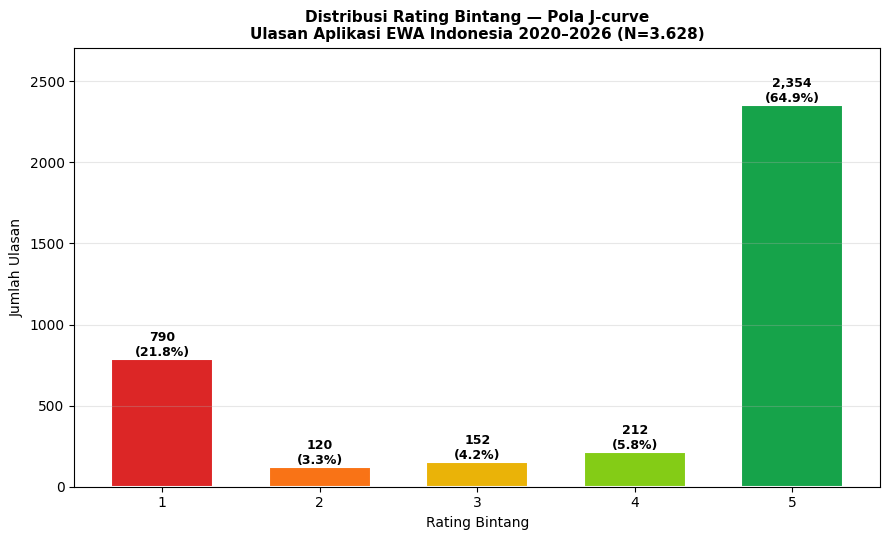

In [6]:
# Distribusi rating bintang keseluruhan (pola J-curve)
dist = df_raw['rating'].value_counts().sort_index()
total = len(df_raw)
pct = (dist / total * 100)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(dist.index, dist.values, color=['#dc2626','#f97316','#eab308','#84cc16','#16a34a'],
              edgecolor='white', linewidth=1.5, width=0.65)
for b, v, p in zip(bars, dist.values, pct):
    ax.annotate(f"{v:,}\n({p:.1f}%)", (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom', fontsize=9, fontweight='600')
ax.set_xlabel("Rating Bintang", fontsize=10)
ax.set_ylabel("Jumlah Ulasan", fontsize=10)
ax.set_title("Distribusi Rating Bintang — Pola J-curve\n"
             "Ulasan Aplikasi EWA Indonesia 2020–2026 (N=3.628)",
             fontsize=11, fontweight='bold')
ax.set_xticks([1,2,3,4,5]); ax.set_ylim(0, max(dist.values)*1.15)
ax.grid(axis='y', alpha=0.3)
ekstrem = pct.get(1,0) + pct.get(5,0)
tengah  = pct.get(3,0)
print("=" * 60)
print("PENJELASAN POLA J-CURVE")
print("=" * 60)
print(f"Bintang ekstrem (1 + 5) : {ekstrem:.1f}% dari seluruh ulasan")
print(f"Bintang tengah (3)       : {tengah:.1f}% saja")
print("-" * 60)
print("J-curve = distribusi rating yang menumpuk di dua kutub (1 dan 5)")
print("dengan lembah di tengah (2-4). Fenomena umum pada ulasan aplikasi:")
print("pengguna cenderung menulis ulasan hanya saat SANGAT puas atau")
print("SANGAT kecewa. Implikasi penelitian: rating bintang bersifat bias")
print("polar -> sinyal sentimen berbasis TEKS (ACSC) lebih informatif")
print("daripada rating, karena menangkap nuansa yang hilang di bintang.")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/TA_ACSC_EWA/01_scraping/data/jcurve_rating.png", dpi=150, bbox_inches='tight')
plt.show()


RINGKASAN KETIMPANGAN VOLUME ANTAR-APLIKASI
Terbesar : Mekari Flex  1,101 ulasan (30.3%)
Terkecil : AyoKasbon       52 ulasan (1.4%)
Rasio    : 21.2× lipat
------------------------------------------------------------
Implikasi: AyoKasbon hanya 1,4% dari total data. Setiap analisis
per-aplikasi untuk AyoKasbon WAJIB disertai confidence interval
(lihat Sel B) dan catatan keterbatasan sampel — tidak bisa
dibandingkan setara dengan Mekari/Wagely yang volumenya ~20× lebih besar.


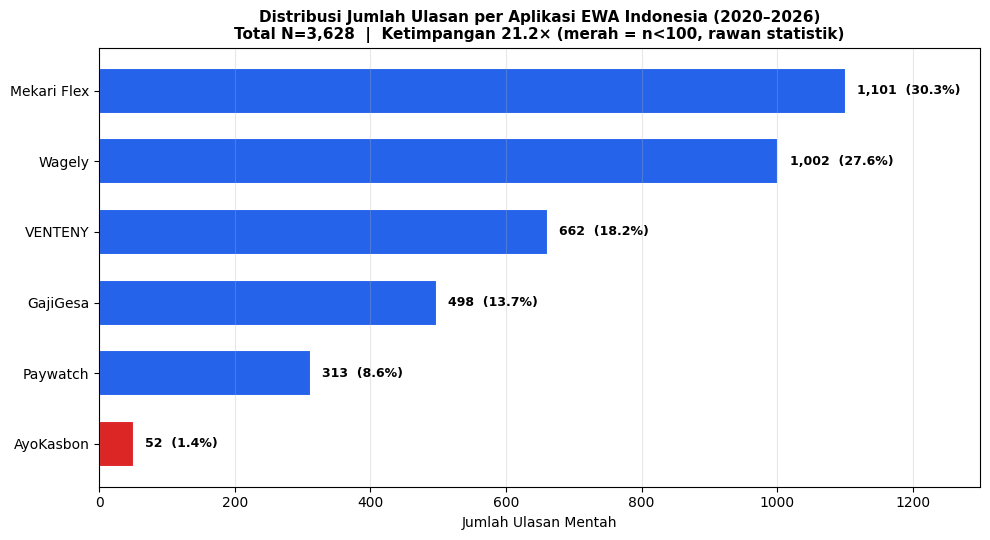

In [7]:
# Distribusi jumlah ulasan mentah per aplikasi
import matplotlib.pyplot as plt

vc = df_raw['app_name'].value_counts().sort_values(ascending=True)  # kecil->besar (utk barh)
total = len(df_raw)

# Konvensi warna KONSISTEN dgn Sel B: merah = n<100 (rawan statistik), biru = memadai
colors = ['#dc2626' if n < 100 else '#2563eb' for n in vc.values]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(range(len(vc)), vc.values, color=colors,
               edgecolor='white', linewidth=1.5, height=0.65)
for i, (app, n) in enumerate(zip(vc.index, vc.values)):
    ax.annotate(f"{n:,}  ({n/total*100:.1f}%)", (n, i), xytext=(8, 0),
                textcoords='offset points', va='center', fontsize=9, fontweight='600')

ax.set_yticks(range(len(vc)))
ax.set_yticklabels(vc.index, fontsize=10)
ax.set_xlabel("Jumlah Ulasan Mentah", fontsize=10)
ax.set_title("Distribusi Jumlah Ulasan per Aplikasi EWA Indonesia (2020–2026)\n"
             f"Total N={total:,}  |  Ketimpangan {vc.max()/vc.min():.1f}× "
             f"(merah = n<100, rawan statistik)",
             fontsize=11, fontweight='bold')
ax.set_xlim(0, vc.max() * 1.18)
ax.grid(axis='x', alpha=0.3)

print("=" * 60)
print("RINGKASAN KETIMPANGAN VOLUME ANTAR-APLIKASI")
print("=" * 60)
print(f"Terbesar : {vc.idxmax():<12} {vc.max():>5,} ulasan ({vc.max()/total*100:.1f}%)")
print(f"Terkecil : {vc.idxmin():<12} {vc.min():>5,} ulasan ({vc.min()/total*100:.1f}%)")
print(f"Rasio    : {vc.max()/vc.min():.1f}× lipat")
print("-" * 60)
print("Implikasi: AyoKasbon hanya 1,4% dari total data. Setiap analisis")
print("per-aplikasi untuk AyoKasbon WAJIB disertai confidence interval")
print("(lihat Sel B) dan catatan keterbatasan sampel — tidak bisa")
print("dibandingkan setara dengan Mekari/Wagely yang volumenya ~20× lebih besar.")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/TA_ACSC_EWA/01_scraping/data/distribusi_ulasan_per_app.png", dpi=150, bbox_inches='tight')
plt.show()


RINGKASAN TEMPORAL
Rentang    : 2020–2026 (2026 sebagian: Jan–Mei)
Puncak     : 2024 (996 ulasan)
Rating tertinggi: 2021 (4.70)
Rating terendah : 2023 (3.30)
------------------------------------------------------------
Catatan: rating tinggi di masa awal (2020–2021) lalu menurun
2022–2023 adalah POLA TERAMATI, bukan klaim kausal. Interpretasi
faktor penyebab (pertumbuhan pengguna, perubahan fitur, dsb) perlu
bukti tambahan dan sebaiknya dihindari sebagai kesimpulan.


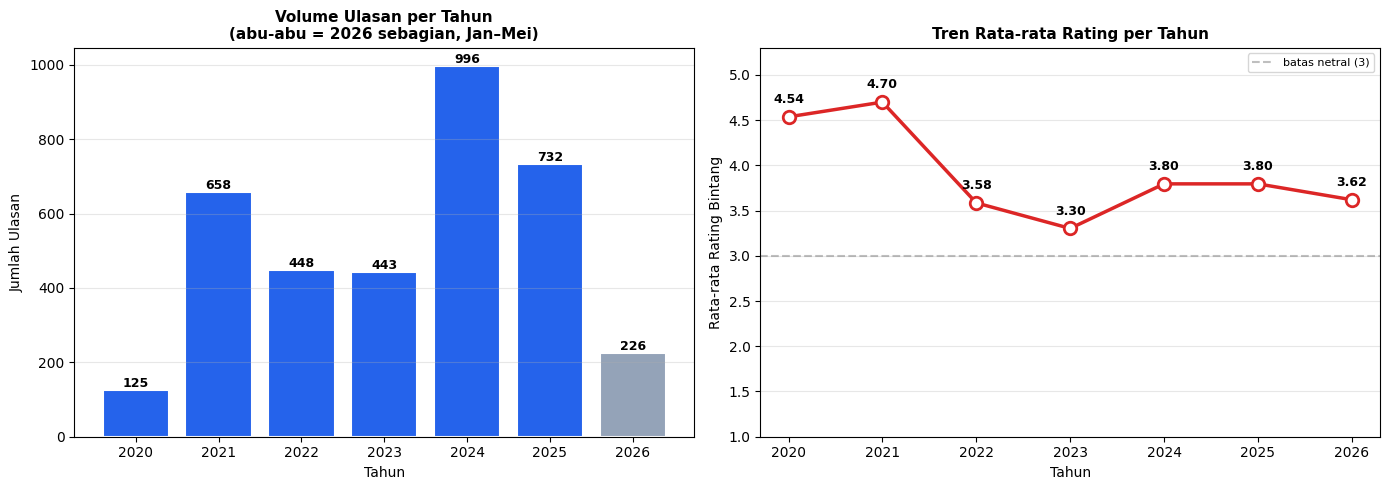

In [8]:
# Distribusi temporal ulasan per tahun
import matplotlib.pyplot as plt

df_raw['_dt']   = pd.to_datetime(df_raw['review_date'], errors='coerce')
df_raw['_year'] = df_raw['_dt'].dt.year
d = df_raw.dropna(subset=['_year']).copy()
d['_year'] = d['_year'].astype(int)

per_year   = d['_year'].value_counts().sort_index()
rating_year = d.groupby('_year')['rating'].mean()
tahun = per_year.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: volume ulasan per tahun (2026 ditandai sebagian)
colors1 = ['#94a3b8' if y == 2026 else '#2563eb' for y in tahun]
bars = ax1.bar(tahun, per_year.values, color=colors1, edgecolor='white', linewidth=1.5)
for b, n in zip(bars, per_year.values):
    ax1.annotate(f"{n:,}", (b.get_x()+b.get_width()/2, n), ha='center', va='bottom',
                 fontsize=9, fontweight='600')
ax1.set_xlabel("Tahun"); ax1.set_ylabel("Jumlah Ulasan")
ax1.set_title("Volume Ulasan per Tahun\n(abu-abu = 2026 sebagian, Jan–Mei)", fontweight='bold', fontsize=11)
ax1.set_xticks(tahun); ax1.grid(axis='y', alpha=0.3)

# Panel 2: tren rata-rata rating (sinyal sentimen kasar)
ax2.plot(tahun, rating_year.values, marker='o', markersize=9, linewidth=2.5,
         color='#dc2626', markerfacecolor='white', markeredgewidth=2)
for y, r in zip(tahun, rating_year.values):
    ax2.annotate(f"{r:.2f}", (y, r), xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='600')
ax2.axhline(3, color='gray', ls='--', alpha=0.5, label='batas netral (3)')
ax2.set_xlabel("Tahun"); ax2.set_ylabel("Rata-rata Rating Bintang")
ax2.set_title("Tren Rata-rata Rating per Tahun", fontweight='bold', fontsize=11)
ax2.set_xticks(tahun); ax2.set_ylim(1, 5.3); ax2.grid(axis='y', alpha=0.3); ax2.legend(fontsize=8)

print("=" * 60)
print("RINGKASAN TEMPORAL")
print("=" * 60)
print(f"Rentang    : {int(min(tahun))}–{int(max(tahun))} (2026 sebagian: Jan–Mei)")
print(f"Puncak     : {int(per_year.idxmax())} ({per_year.max():,} ulasan)")
print(f"Rating tertinggi: {rating_year.idxmax()} ({rating_year.max():.2f})")
print(f"Rating terendah : {rating_year.idxmin()} ({rating_year.min():.2f})")
print("-" * 60)
print("Catatan: rating tinggi di masa awal (2020–2021) lalu menurun")
print("2022–2023 adalah POLA TERAMATI, bukan klaim kausal. Interpretasi")
print("faktor penyebab (pertumbuhan pengguna, perubahan fitur, dsb) perlu")
print("bukti tambahan dan sebaiknya dihindari sebagai kesimpulan.")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/TA_ACSC_EWA/01_scraping/data/distribusi_temporal.png", dpi=150, bbox_inches='tight')
plt.show()

JUSTIFIKASI max_length = 128
median=7 | mean=10.4 | max=100 kata
  persentil-75: 15 kata
  persentil-90: 26 kata
  persentil-95: 32 kata
  persentil-99: 50 kata
------------------------------------------------------------
Ulasan > 85 kata (~128 token): 2 (0.06%)
-> Truncation di 128 token menyentuh ≤0.06% data. max_length=128 MEMADAI.

CATATAN RIGOR: word count di sini adalah proxy pada teks MENTAH.
Verifikasi token PASTI (tokenizer IndoBERT pada teks BERSIH) lebih
tepat ditempatkan di NB05; teks bersih hanya lebih PENDEK (noise
dihapus), jadi proxy ini bersifat konservatif (over-estimate).


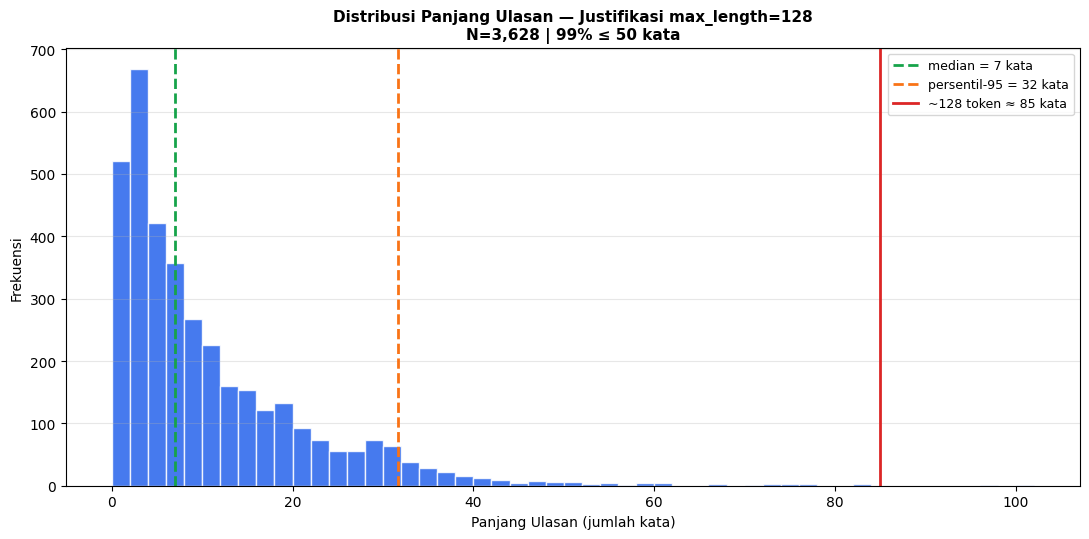

In [9]:
# Distribusi panjang ulasan (justifikasi max_length=128; word count sebagai proxy)
import numpy as np
import matplotlib.pyplot as plt

df_raw['_wc'] = df_raw['review_text'].astype(str).str.split().str.len()
wc = df_raw['_wc']

# Heuristik: subword IndoBERT ~1,5 token/kata -> 128 token ≈ 85 kata
AMBANG_KATA = 85
p95 = np.percentile(wc, 95)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(wc, bins=range(0, int(wc.max())+3, 2), color='#2563eb', edgecolor='white', alpha=0.85)
ax.axvline(wc.median(), color='#16a34a', ls='--', lw=2, label=f'median = {wc.median():.0f} kata')
ax.axvline(p95, color='#f97316', ls='--', lw=2, label=f'persentil-95 = {p95:.0f} kata')
ax.axvline(AMBANG_KATA, color='#dc2626', ls='-', lw=2, label=f'~128 token ≈ {AMBANG_KATA} kata')
ax.set_xlabel("Panjang Ulasan (jumlah kata)"); ax.set_ylabel("Frekuensi")
ax.set_title("Distribusi Panjang Ulasan — Justifikasi max_length=128\n"
             f"N={len(wc):,} | 99% ≤ {np.percentile(wc,99):.0f} kata", fontweight='bold', fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

lebih = (wc > AMBANG_KATA).sum()
print("=" * 60)

print("JUSTIFIKASI max_length = 128")
print("=" * 60)
print(f"median={wc.median():.0f} | mean={wc.mean():.1f} | max={wc.max()} kata")
for p in [75, 90, 95, 99]:
    print(f"  persentil-{p}: {np.percentile(wc,p):.0f} kata")
print("-" * 60)
print(f"Ulasan > {AMBANG_KATA} kata (~128 token): {lebih} ({lebih/len(wc)*100:.2f}%)")
print(f"-> Truncation di 128 token menyentuh ≤{lebih/len(wc)*100:.2f}% data. max_length=128 MEMADAI.")
print()
print("CATATAN RIGOR: word count di sini adalah proxy pada teks MENTAH.")
print("Verifikasi token PASTI (tokenizer IndoBERT pada teks BERSIH) lebih")
print("tepat ditempatkan di NB05; teks bersih hanya lebih PENDEK (noise")
print("dihapus), jadi proxy ini bersifat konservatif (over-estimate).")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/TA_ACSC_EWA/01_scraping/data/distribusi_panjang.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/TA_ACSC_EWA"
OUT_DIR  = f"{BASE}/01_scraping/data"
RAW_PATH = f"{OUT_DIR}/dataset_raw_ewa_acsc.csv"

APLIKASI = {
    'VENTENY'    : 'app.fortuna.venteny',
    'Mekari Flex': 'com.mekari.flex',
    'Paywatch'   : 'my.paywatchglobal.paywatch',
    'Wagely'     : 'com.wagely.android',
    'GajiGesa'   : 'com.gajigesanative',
    'AyoKasbon'  : 'com.kasbon.id',
}
TANGGAL_MULAI  = '2020-01-01'
TANGGAL_AKHIR  = '2026-05-31'
print(f"Konfigurasi: {len(APLIKASI)} aplikasi | rentang {TANGGAL_MULAI} s.d. {TANGGAL_AKHIR}")


Konfigurasi: 6 aplikasi | rentang 2020-01-01 s.d. 2026-05-31


In [ ]:
df_raw = pd.read_csv(RAW_PATH)
print(f"Data mentah dimuat: {len(df_raw)} baris")
print("Kolom:", df_raw.columns.tolist())
print("\nRentang tanggal:", df_raw['review_date'].min(), "s.d.", df_raw['review_date'].max())

Data mentah dimuat: 3628 baris
Kolom: ['app_name', 'package_name', 'review_id', 'user_name', 'review_text', 'rating', 'review_date']

Rentang tanggal: 2020-04-16 s.d. 2026-05-14


In [ ]:
# Pemisahan CSV per aplikasi dari dataset mentah tersimpan.
import re

def nama_file_app(app):
    return "raw_" + re.sub(r"\s+", "_", app.strip().lower()) + ".csv"

total_pecahan = 0
print("Pemisahan file CSV per aplikasi:")
for app, grup in df_raw.groupby("app_name"):
    fn = nama_file_app(app)
    grup.to_csv(f"{OUT_DIR}/{fn}", index=False)
    total_pecahan += len(grup)
    print(f"  {app:<12} -> {fn:<22} {len(grup):5d} baris")

print("-" * 55)
print(f"Jumlah seluruh file : {total_pecahan}")
print(f"Total dataset utama : {len(df_raw)}")
assert total_pecahan == len(df_raw)
print("Rekonsiliasi: semua baris terbagi utuh per aplikasi.")


Pemisahan file CSV per aplikasi:
  AyoKasbon    -> raw_ayokasbon.csv         52 baris
  GajiGesa     -> raw_gajigesa.csv         498 baris
  Mekari Flex  -> raw_mekari_flex.csv     1101 baris
  Paywatch     -> raw_paywatch.csv         313 baris
  VENTENY      -> raw_venteny.csv          662 baris
  Wagely       -> raw_wagely.csv          1002 baris
-------------------------------------------------------
Jumlah seluruh file : 3628
Total dataset utama : 3628
Rekonsiliasi: semua baris terbagi utuh per aplikasi.
